# 당뇨병 여부 분류
1. 데이터 로드
2. train/ valid / test 데이터 분리
3. 파이프라인(결측치 처리 및 정규화)
4. Tensor 변환
5. 미니배치 학습 준비
6. 다층 퍼셉트론 모델 준비
7. Optimizer / Scheduler / EarlyStopping 적용하여 학습
8. 학습 시각화
9. 각종 지표 확인
10. optimizer 여러개 성능 비교
11. K-Fold Cross Validation

- 데이터 셋
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

- y : Outcome  
0 -> 당뇨병 음성    
1 -> 당뇨병 양성

In [11]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install tqdm   
# 커널 가상환경에 설치

Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader  # Tensor 데이터셋 / 미니배치 로더

import kagglehub            # 캐들 데이터셋 다운로드용
from tqdm.auto import tqdm  # 프로그래스 바

from sklearn.model_selection import train_test_split, StratifiedGroupKFold  # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline       # 전처리 과정 통합
from sklearn.impute import SimpleImputer    #
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,average_precision_score,
    confusion_matrix,classification_report
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [14]:
SEED = 42   # 랜덤 시드값
random.seed(SEED)       # 파이썬 랜덤 시드 고정
np.random.seed(SEED)    # numpy 랜덤 시드 고정
torch.manual_seed(SEED) # Pytorch CPU 랜덤 시드 고정


# GPU 가용시
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)    # Pytorch GPU 랜덤 시드 고정


# GPU 기용시 device = 'cuda', dkslaus 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [20]:
data_path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(data_path, csv_files[0]))
print(df.shape)
df

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

|컬럼명|설명|
|---|---|
|Pregnancies|임신 횟수|
|Glucose|포도당 수치|
|BloodPressure|혈압|
|SkinThickness|피부 두께|
|Insulin|인슐린 수치|
|BMI|체질량 지후|
|DiabetesPedigreeFunction|당뇨병 가족력 지표|
|Age|나이|
|Outcome|당뇨병 여부|


,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


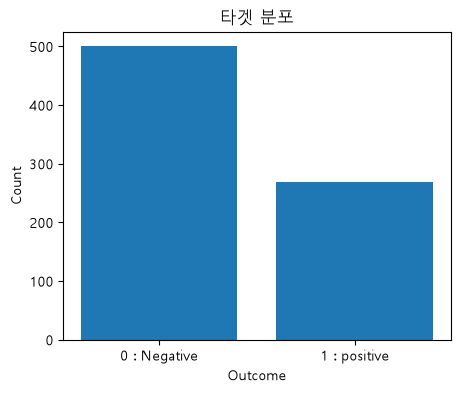

In [26]:
target_counts = df['Outcome'].value_counts().sort_index()               # 클래스별 데이터 갯수
target_ratio = df['Outcome'].value_counts(normalize=True).sort_index()  # 클래스별 비율

# 갯수와 비율을 표로 출력
display(pd.DataFrame({
    'count' : target_counts,
    'ratio' : target_ratio
}))

plt.figure(figsize=(5,4))
plt.bar(['0 : Negative','1 : positive'], target_counts.values)  # 클래스별 갯수 막대그래프
plt.title('타겟 분포')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

### 2. train / valid / test 데이터 분리

In [27]:
X = df.drop(columns= 'Outcome')
y = df['Outcome']

print(X.shape,y.shape)

(768, 8) (768,)


In [29]:
# test데이터를 8:2 비율로 나눈다
X_train_valid,X_test,y_train_valid,y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state= SEED,
    stratify= y
)

# 남은 80% 중 8:2 비율로 Train/valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,y_train_valid,
    test_size= 0.2,
    random_state= SEED,
    stratify= y_train_valid
)



print(f"X_trian :{X_train.shape},X_valid:{X_valid.shape}X_Test:{X_test.shape}")
print(f"y_trian :{y_train.shape},y_valid:{y_valid.shape}y_Test:{y_test.shape}")

X_trian :(491, 8),X_valid:(123, 8)X_Test:(154, 8)
y_trian :(491,),y_valid:(123,)y_Test:(154,)


### 3. 전처리 파이프라인

In [31]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),    # 결측치가 있다면 중앙값 대체
    ('scaler', StandardScaler())    # 평균 0, 표준편차 1 표준화
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train) # train 데이터는 전처리 기준 학습 / 변환
X_valid_scaled = preprocess_pipeline.transform(X_valid)     # valid 데이터는 학습된 기준으로 변환
X_test_scaled = preprocess_pipeline.transform(X_test)       # test 데이터도 학습된 기준으로 변환


print(X_train_scaled.shape,X_valid_scaled.shape,X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


### 4. Tensor 형태로 변환

In [48]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor =torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.tensor(y_train.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_valid_tensor = torch.tensor(y_valid.to_numpy(),dtype = torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test.to_numpy(),dtype = torch.float32).reshape(-1,1)

print("X_train_tensor : ",X_train_tensor.size())
print("X_valid_tensor : ", X_valid_tensor.size())
print("X_test_tensor : ", X_test_tensor.size())
print("y_train_tensor : ", y_train_tensor.size())
print("y_valid_tensor : ", y_valid_tensor.size())
print("y_test_tensor : " ,y_test_tensor.size())

X_train_tensor :  torch.Size([491, 8])
X_valid_tensor :  torch.Size([123, 8])
X_test_tensor :  torch.Size([154, 8])
y_train_tensor :  torch.Size([491, 1])
y_valid_tensor :  torch.Size([123, 1])
y_test_tensor :  torch.Size([154, 1])


### 5. 미니배치 학습 준비

In [ ]:
BATCH_SIZE =32

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor , y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

# DataLoader를 사용해서 미니배치 단위로 데이터를 나눠 학습
train_loader = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    shuffle= True
)

# 검증 데이터셋과 테스트 데이터셋을 만들기

valid_loader =  DataLoader(
    valid_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False
)

test_loader =  DataLoader(
    test_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False
)

print(len(train_loader),len(valid_loader),len(test_loader))

16 4 5


### 6. 다층 퍼셉트론 모델 정의

In [ ]:
class DiabetesMLP(nn.Module):

    def __init__(self,input_dim,hidden_dims=(64,32,16), dropout=0.2, activation='silu'):
        super().__init__()  # 부모 클래스 초기화

        layers = [] # 신경망 계층을 모두 저장할 리스트
        prev_dim = input_dim    # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화


            # 활성화 함수 추가 (비선형성 추가)
            if activation =='relu':
                layers.append(nn.ReLU())
            elif activation =='gelu':
                layers.append(nn.GELU())
            elif activation =='silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError("활성화 함수는 relu,gelu,silu 중 하나로 선택해 주세요!")

            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim,1))
        self.net = nn.Sequential(*layers)


    def forward(self,x):
        return self.net(x)